In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


## Simulaatio

In [5]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [74]:
AC_stark_guess_vals=[-0.006, -0.009, -0.013, -0.019, -0.028, -0.04, -0.056, -0.077, -0.1, -0.14, -0.17, -0.22, -0.26, -0.31, -0.35, -0.38, -0.41, -0.43, -0.42, -0.47]
rabi_guess_vals=[np.float64(0.00013803783688753186), np.float64(0.0001153749572060944), np.float64(0.0002750176156511674), np.float64(0.0005387576896729024), np.float64(0.0007680885420262695), np.float64(0.0012362943219436163), np.float64(0.0020271332765942614), np.float64(0.003223173378549984), np.float64(0.005914878408746056), np.float64(0.006041410169833008), np.float64(0.012784334258049947), np.float64(0.017239249686223434), np.float64(0.022464722100488756), np.float64(0.0286630313041743), np.float64(0.03506454257242411), np.float64(0.04207385918511013), np.float64(0.04898318827444888), np.float64(0.05505169953810089), np.float64(0.0798398096366233), np.float64(0.06271197232235143)]

In [79]:
def sim_pulse(f_d,A,evolution,dim,f_rabi,K=20,use_avg=False):
    T_floquet = 2*np.pi/(f_d) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä

    N_pulse=int(1/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse = pulses.Pulse(f_d,f_ef,[pulses.one],[N_pulse],time_unit=dt,offset_input=0)
    U_floquet=evolution.U_floquet(A*pulse.raw[0:K],dt)
    
    #Simuloitujen pulssien määrä, jaetaan kahdellakymmenellä koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (20dt)
    N_sim=int(N_pulse/K)+1
    
    #Lopulliset todennäköisyydet eripituisten pulssien jälkeen
    last_vals=[]

    psi = np.zeros(dim, dtype=complex) #Alustetaan kubitin tila e-tilaan
    psi[1] = 1
    
    #Simulaatio pulsseille
    for i in range(0,N_sim):
        psi = U_floquet @ psi #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla
        last_vals.append(psi)

    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([np.abs(a[1])**2 for a in last_vals])
    f_vals = np.array([np.abs(a[2])**2 for a in last_vals])

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    T_pulse = np.argmax(e_vals)*K*dt

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_sim)*K*dt

    if use_avg:
        e_avg=np.mean(e_vals)
        f_avg=np.mean(f_vals)
        return (e_avg,f_avg,T_pulse,last_vals,pulse_times)
    else:
        #e-tason suurin todennäköisyys
        excited_max=max(e_vals)
        #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
        f_max=max(f_vals)
        return (excited_max,f_max,T_pulse,last_vals,pulse_times)

def find_params(f_d,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range,max_range):
        delta=AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)

        sim_vals = sim_pulse(f_d+delta,A,evolution,dim,f_rabi,use_avg=True)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_f_vals)
    plt.xlabel("ω_d-ω_q/3 (GHz)")
    plt.ylabel("Suurin f-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_f_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

[ 1.63216151  1.98358382  2.38668463  2.84312903  3.35316681  3.91535193
  4.52630176  5.18051886  5.87029693  6.5857302   7.31484041  8.04382903
  8.75745395  9.43952081 10.07346982 10.64302999 11.13290589 11.52945675
 11.82132634 11.99998281]


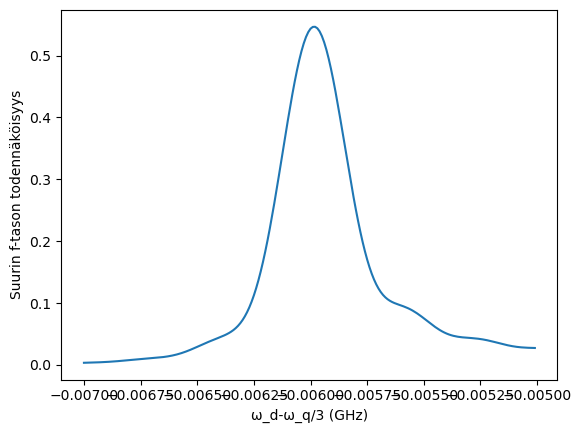

Amplitudi (GHz): 1.6321615118047819
Ajotaajuus AC Stark (GHz): -0.00598
E-tason suurin todennäköisyys: 0.9999969886330731
F-tason suurin todennäköisyys: 0.9907449616511219
Rabi-taajuus (fourier):  8.282198323145796e-05


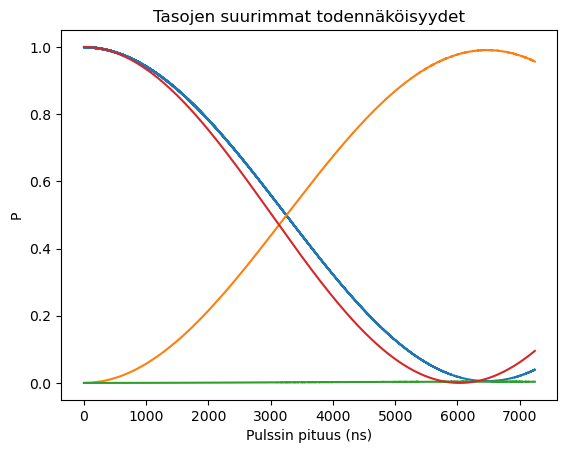

---------------------------------------------


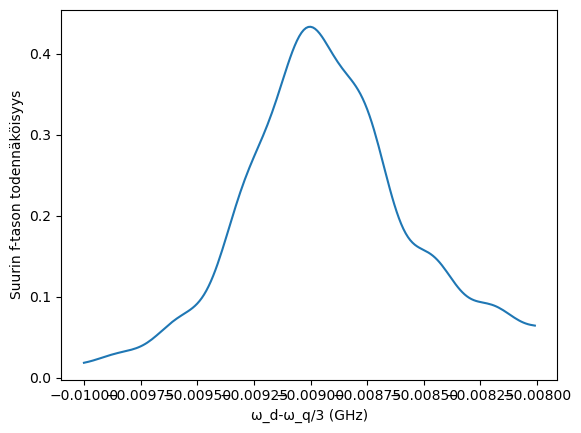

Amplitudi (GHz): 1.9835838170220397
Ajotaajuus AC Stark (GHz): -0.009
E-tason suurin todennäköisyys: 0.9999953943386979
F-tason suurin todennäköisyys: 0.9940997606366988
Rabi-taajuus (fourier):  0.00013844864265125014


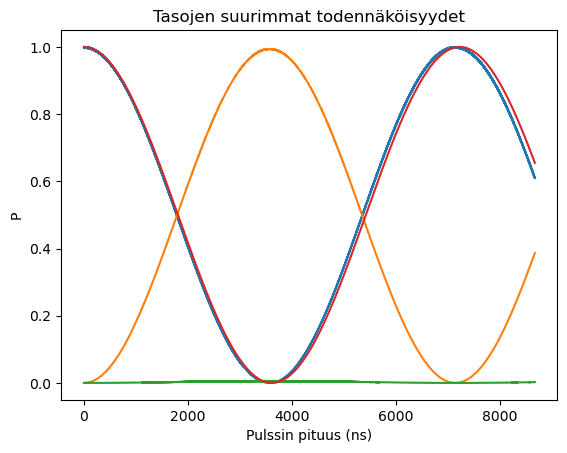

---------------------------------------------


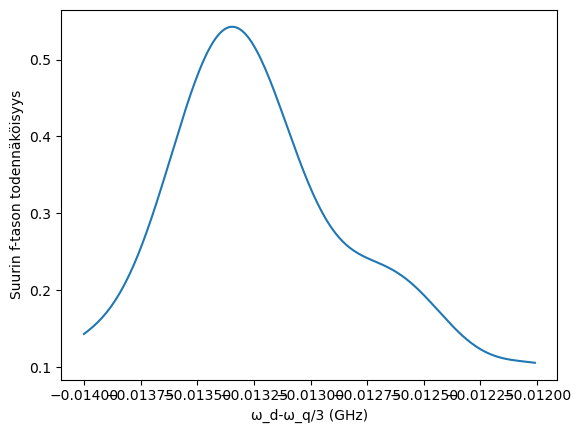

Amplitudi (GHz): 2.386684626179798
Ajotaajuus AC Stark (GHz): -0.013349999999999999
E-tason suurin todennäköisyys: 0.9999889128910839
F-tason suurin todennäköisyys: 0.9895990246671238
Rabi-taajuus (fourier):  0.00024751571220424346


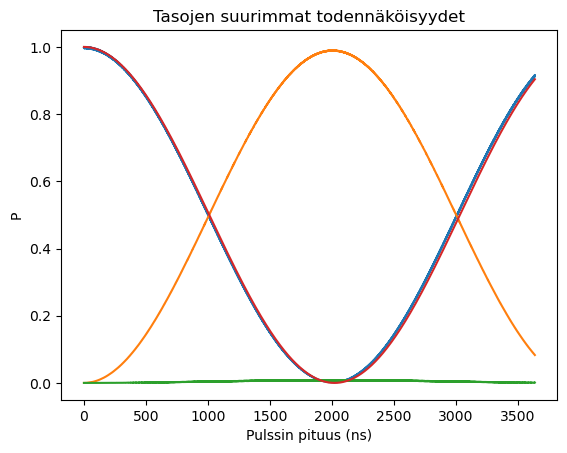

---------------------------------------------


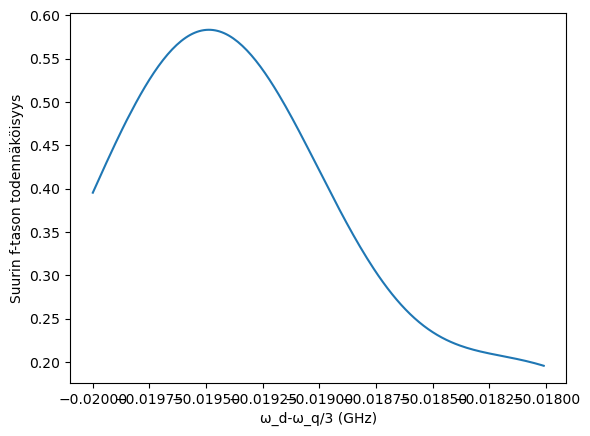

Amplitudi (GHz): 2.843129031183565
Ajotaajuus AC Stark (GHz): -0.01949
E-tason suurin todennäköisyys: 0.9999716672089306
F-tason suurin todennäköisyys: 0.9868215994123499
Rabi-taajuus (fourier):  0.0004309881390221499


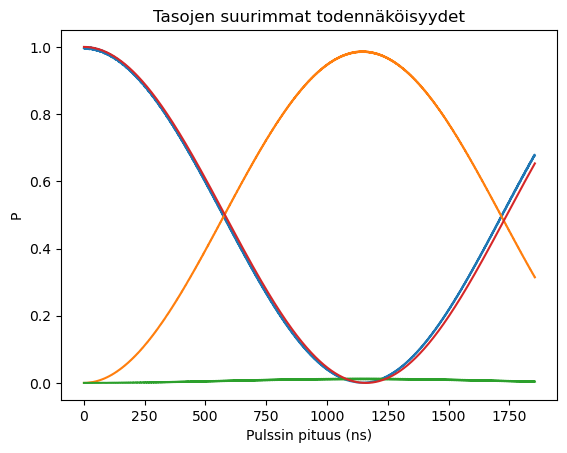

---------------------------------------------


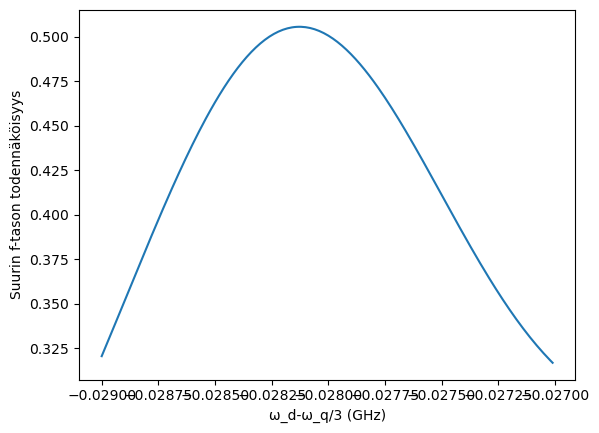

Amplitudi (GHz): 3.3531668149864795
Ajotaajuus AC Stark (GHz): -0.028130000000000002
E-tason suurin todennäköisyys: 0.9999518785164324
F-tason suurin todennäköisyys: 0.9795557864296816
Rabi-taajuus (fourier):  0.0007680486542527282


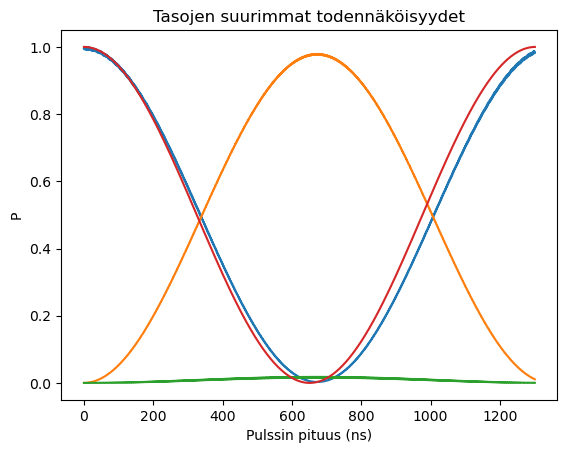

---------------------------------------------


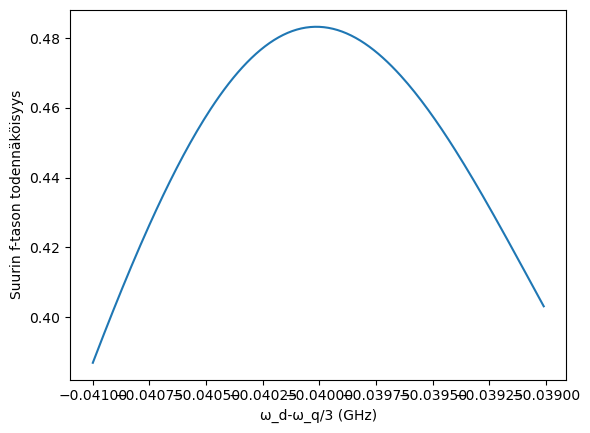

Amplitudi (GHz): 3.915351926432479
Ajotaajuus AC Stark (GHz): -0.040010000000000004
E-tason suurin todennäköisyys: 0.9998307880930274
F-tason suurin todennäköisyys: 0.9720491590431157
Rabi-taajuus (fourier):  0.001236203091695278


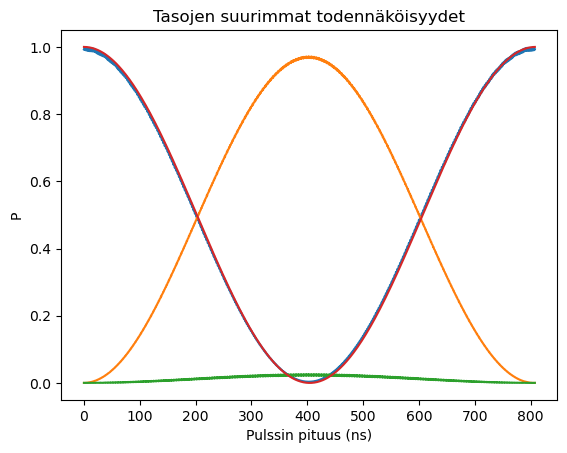

---------------------------------------------


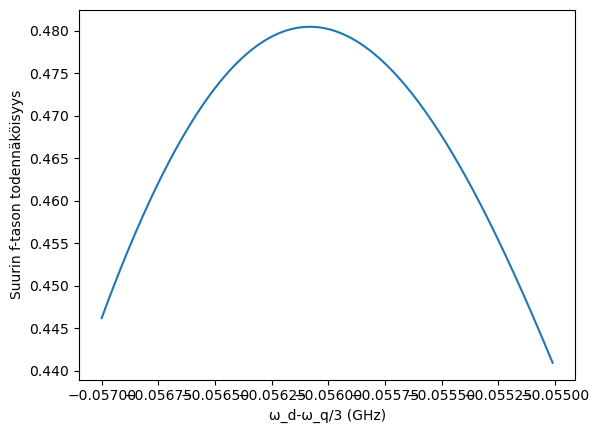

Amplitudi (GHz): 4.526301758481074
Ajotaajuus AC Stark (GHz): -0.05608
E-tason suurin todennäköisyys: 0.9998628428357538
F-tason suurin todennäköisyys: 0.962156158915111
Rabi-taajuus (fourier):  0.0020270083485426716


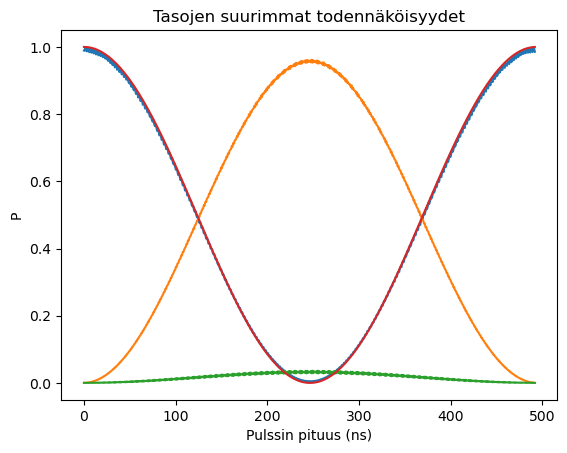

---------------------------------------------


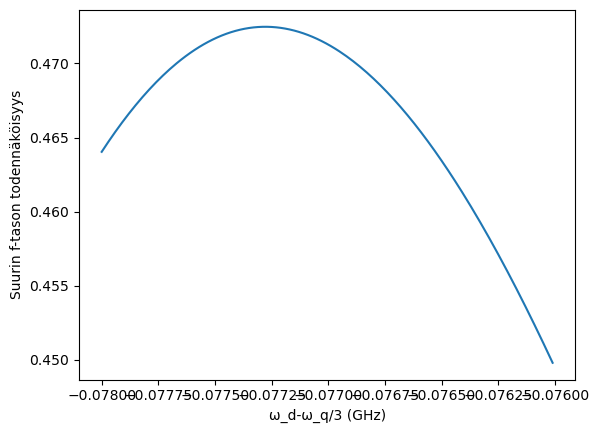

Amplitudi (GHz): 5.180518859655628
Ajotaajuus AC Stark (GHz): -0.07728
E-tason suurin todennäköisyys: 0.9995206943506961
F-tason suurin todennäköisyys: 0.9494049300193328
Rabi-taajuus (fourier):  0.003223139648570838


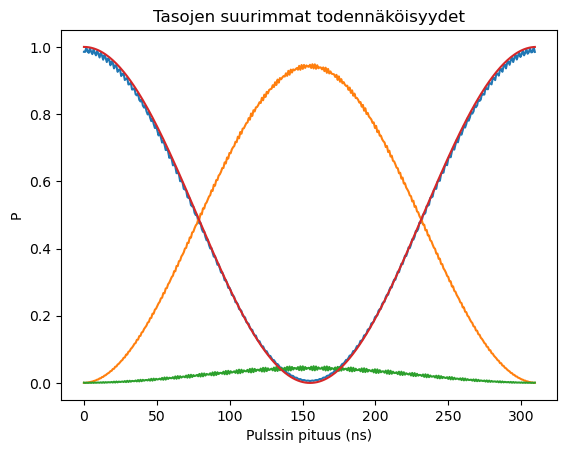

---------------------------------------------


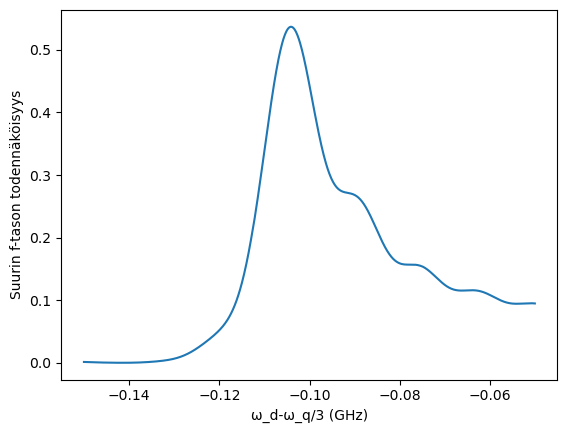

Amplitudi (GHz): 5.870296931902294
Ajotaajuus AC Stark (GHz): -0.10410000000000001
E-tason suurin todennäköisyys: 0.9994372692157127
F-tason suurin todennäköisyys: 0.9388321691099691
Rabi-taajuus (fourier):  0.004730119574170407


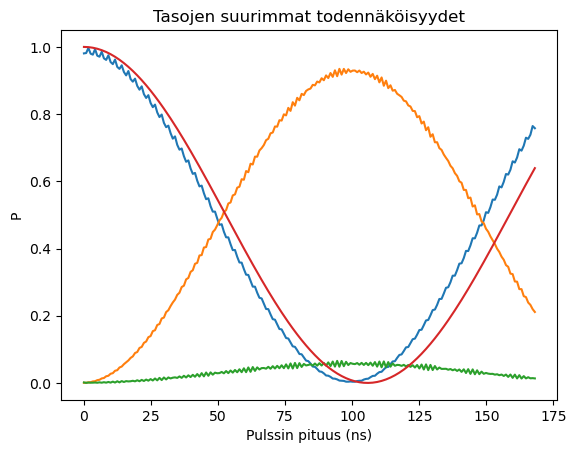

---------------------------------------------


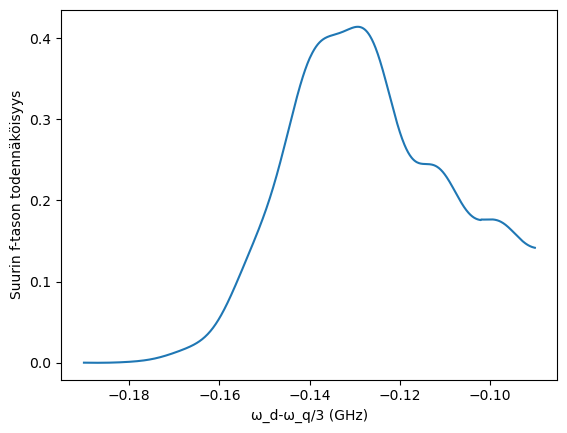

Amplitudi (GHz): 6.585730198561229
Ajotaajuus AC Stark (GHz): -0.12930000000000003
E-tason suurin todennäköisyys: 0.9995545873233752
F-tason suurin todennäköisyys: 0.8210790000934939
Rabi-taajuus (fourier):  0.009061291382497626


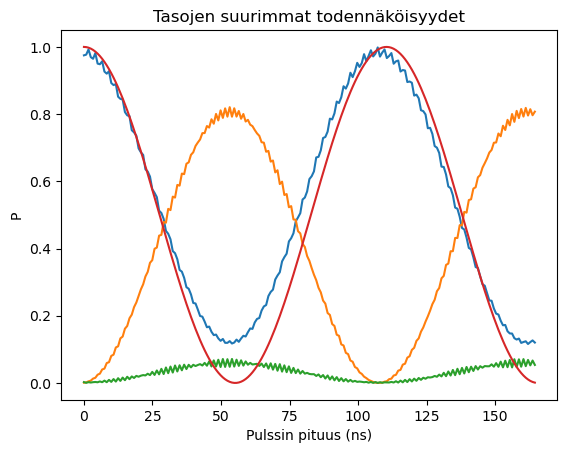

---------------------------------------------


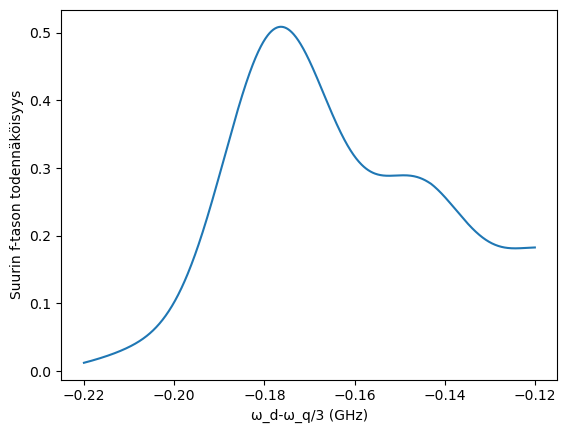

Amplitudi (GHz): 7.314840408481943
Ajotaajuus AC Stark (GHz): -0.1764
E-tason suurin todennäköisyys: 0.9975126071033344
F-tason suurin todennäköisyys: 0.9015338668318327
Rabi-taajuus (fourier):  0.010226046015967721


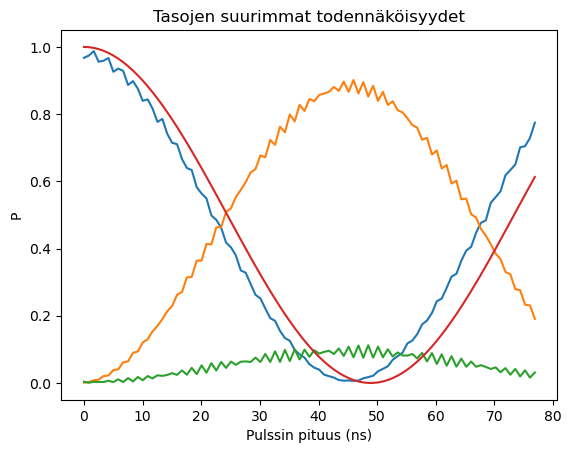

---------------------------------------------


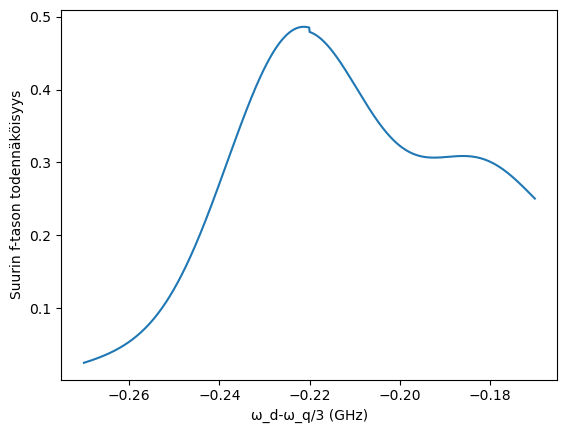

Amplitudi (GHz): 8.043829029021408
Ajotaajuus AC Stark (GHz): -0.2213
E-tason suurin todennäköisyys: 0.9974997998164079
F-tason suurin todennäköisyys: 0.88797264296349
Rabi-taajuus (fourier):  0.015512626003348661


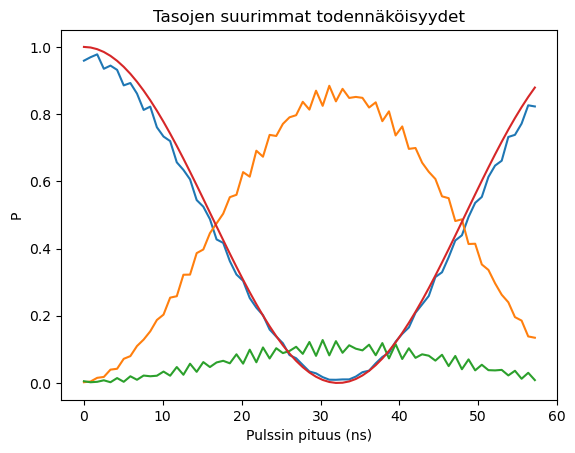

---------------------------------------------


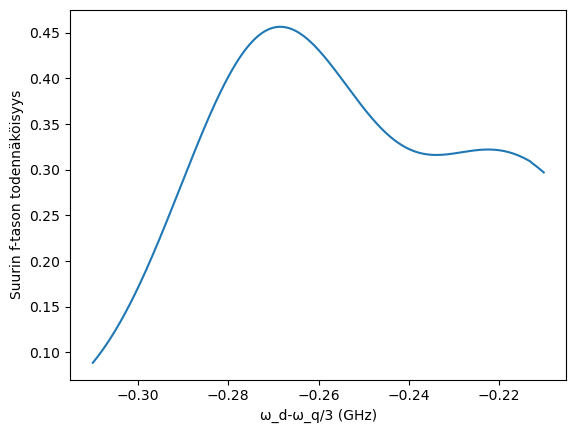

Amplitudi (GHz): 8.757453945499616
Ajotaajuus AC Stark (GHz): -0.2685
E-tason suurin todennäköisyys: 0.9971350901829708
F-tason suurin todennäköisyys: 0.8675740921130553
Rabi-taajuus (fourier):  0.020182358486689065


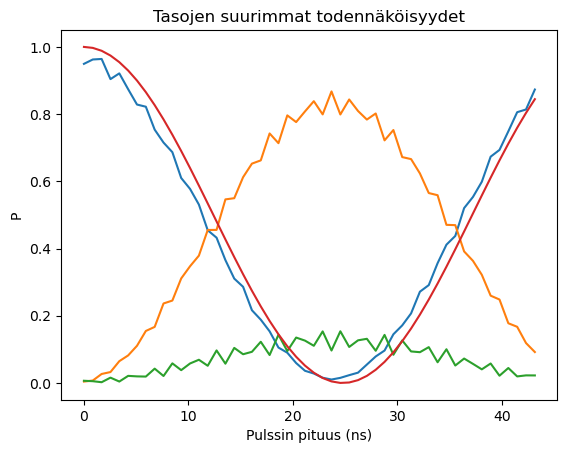

---------------------------------------------


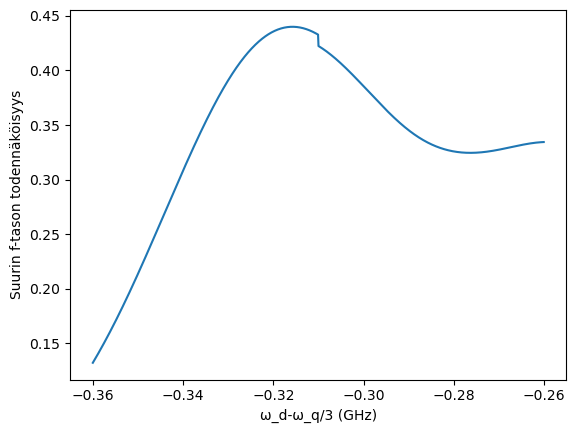

Amplitudi (GHz): 9.43952080995612
Ajotaajuus AC Stark (GHz): -0.31579999999999997
E-tason suurin todennäköisyys: 0.9975372443071752
F-tason suurin todennäköisyys: 0.8462539986241304
Rabi-taajuus (fourier):  0.025776465032221755


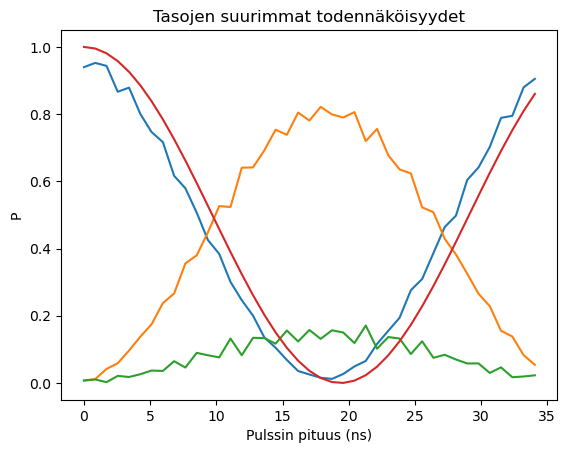

---------------------------------------------


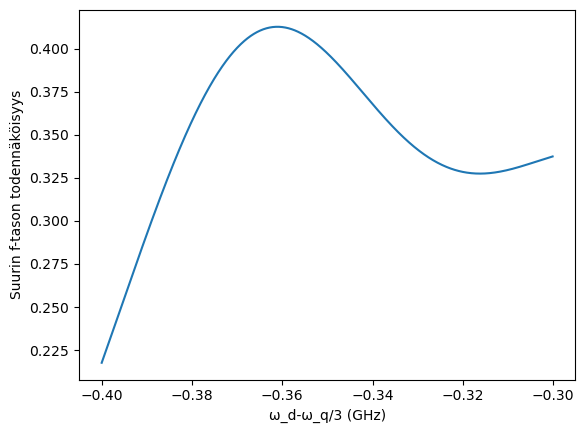

Amplitudi (GHz): 10.073469818207057
Ajotaajuus AC Stark (GHz): -0.3611
E-tason suurin todennäköisyys: 0.9944630094294314
F-tason suurin todennäköisyys: 0.8235276034203531
Rabi-taajuus (fourier):  0.031541931510247305


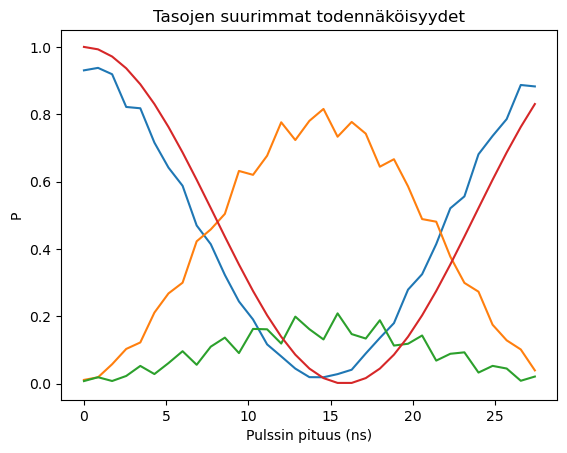

---------------------------------------------


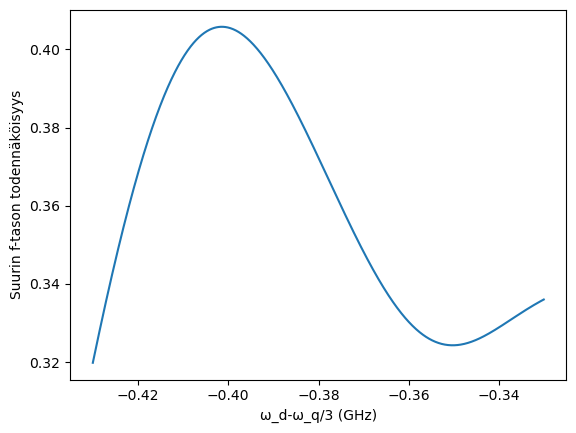

Amplitudi (GHz): 10.643029993643523
Ajotaajuus AC Stark (GHz): -0.4014
E-tason suurin todennäköisyys: 0.9941283036798816
F-tason suurin todennäköisyys: 0.8068595489601688
Rabi-taajuus (fourier):  0.037846875706713495


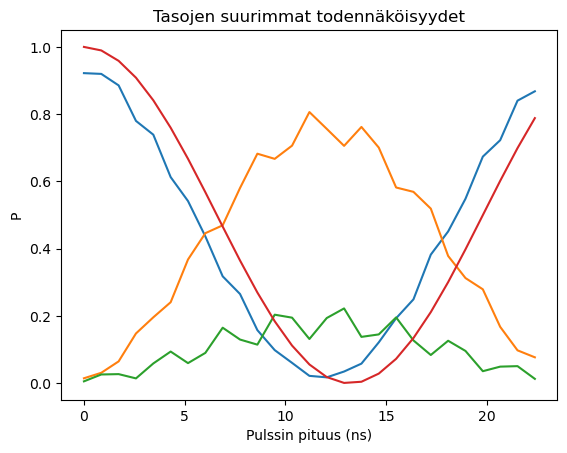

---------------------------------------------


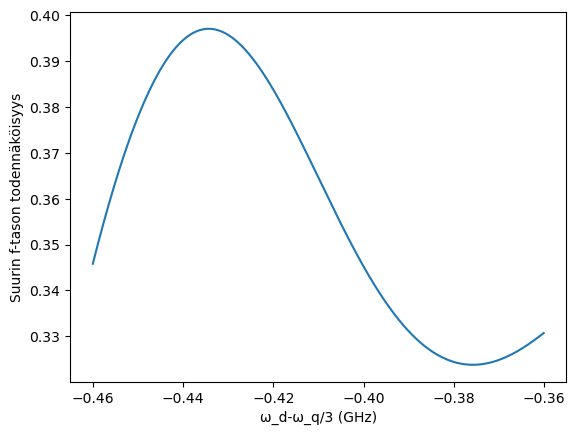

Amplitudi (GHz): 11.13290588719522
Ajotaajuus AC Stark (GHz): -0.43429999999999996
E-tason suurin todennäköisyys: 0.9938826674215081
F-tason suurin todennäköisyys: 0.7956191252788897
Rabi-taajuus (fourier):  0.04406191490001445


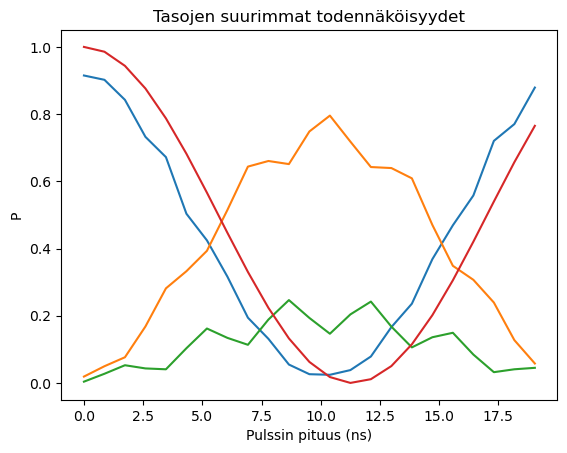

---------------------------------------------


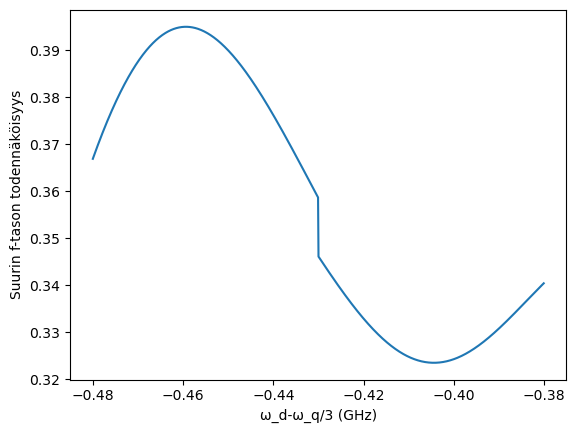

Amplitudi (GHz): 11.529456752990725
Ajotaajuus AC Stark (GHz): -0.4594
E-tason suurin todennäköisyys: 0.9945940577258672
F-tason suurin todennäköisyys: 0.7905500254518153
Rabi-taajuus (fourier):  0.04934599435599502


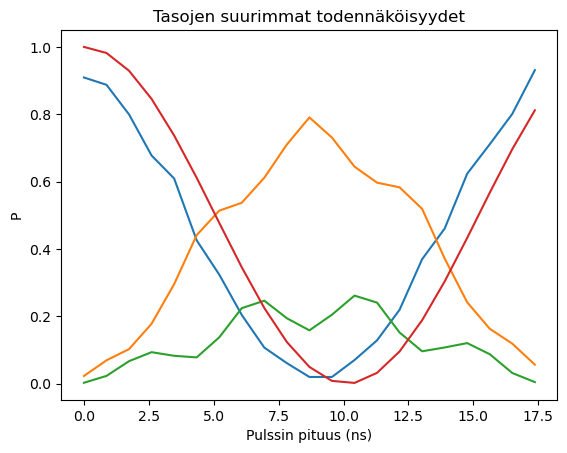

---------------------------------------------


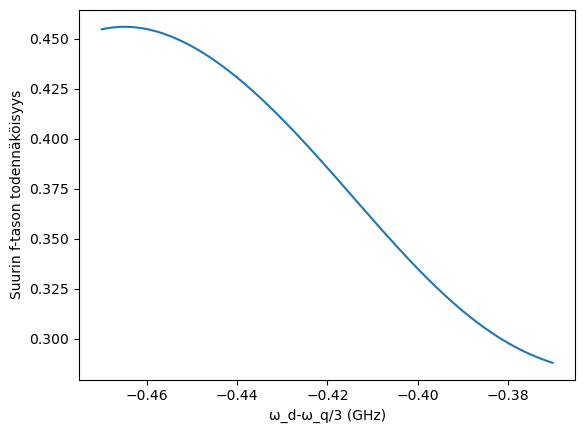

Amplitudi (GHz): 11.821326340273876
Ajotaajuus AC Stark (GHz): -0.46499999999999997
E-tason suurin todennäköisyys: 0.9963682511204068
F-tason suurin todennäköisyys: 0.7475901498687019
Rabi-taajuus (fourier):  0.05554211635202288


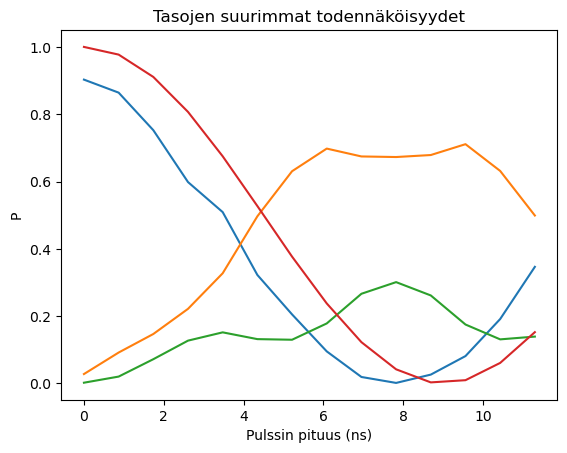

---------------------------------------------


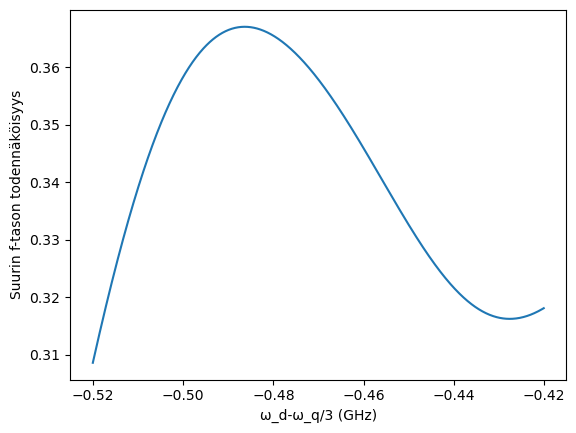

Amplitudi (GHz): 11.999982809097936
Ajotaajuus AC Stark (GHz): -0.4864
E-tason suurin todennäköisyys: 0.993227290875545
F-tason suurin todennäköisyys: 0.7529782247454712
Rabi-taajuus (fourier):  0.05641521400867553


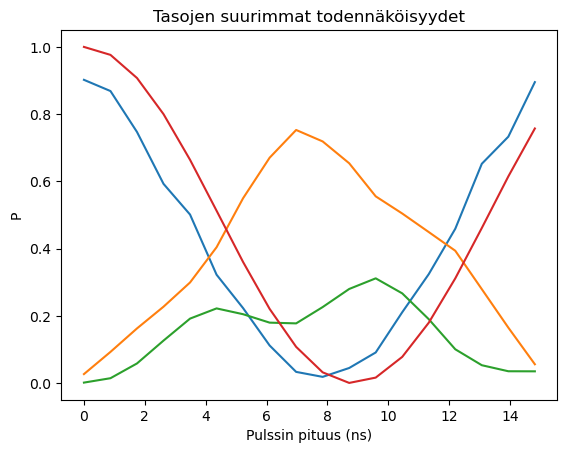

---------------------------------------------
[ 1.63216151  1.98358382  2.38668463  2.84312903  3.35316681  3.91535193
  4.52630176  5.18051886  5.87029693  6.5857302   7.31484041  8.04382903
  8.75745395  9.43952081 10.07346982 10.64302999 11.13290589 11.52945675
 11.82132634 11.99998281]


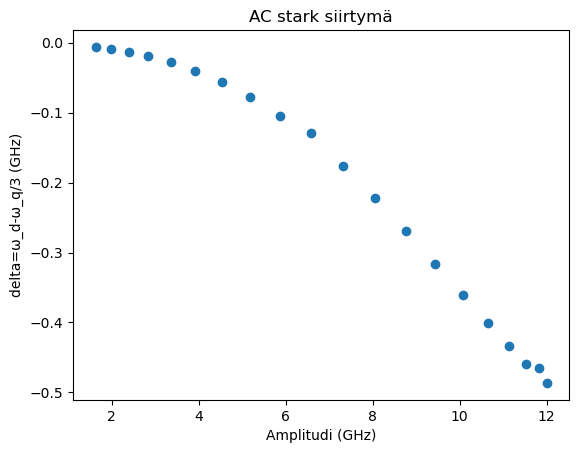

[-0.00598, -0.009, -0.013349999999999999, -0.01949, -0.028130000000000002, -0.040010000000000004, -0.05608, -0.07728, -0.10410000000000001, -0.12930000000000003, -0.1764, -0.2213, -0.2685, -0.31579999999999997, -0.3611, -0.4014, -0.43429999999999996, -0.4594, -0.46499999999999997, -0.4864]


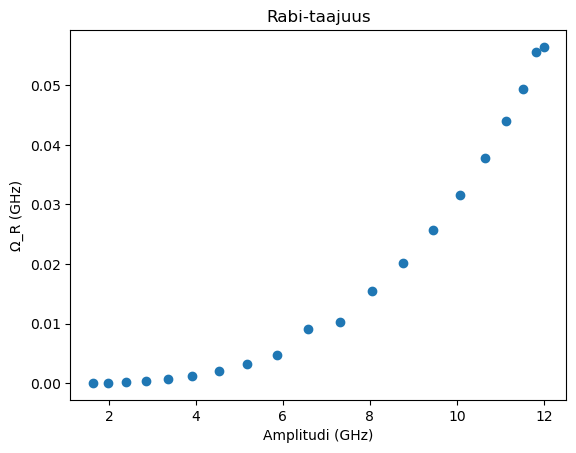

[np.float64(8.282198323145796e-05), np.float64(0.00013844864265125014), np.float64(0.00024751571220424346), np.float64(0.0004309881390221499), np.float64(0.0007680486542527282), np.float64(0.001236203091695278), np.float64(0.0020270083485426716), np.float64(0.003223139648570838), np.float64(0.004730119574170407), np.float64(0.009061291382497626), np.float64(0.010226046015967721), np.float64(0.015512626003348661), np.float64(0.020182358486689065), np.float64(0.025776465032221755), np.float64(0.031541931510247305), np.float64(0.037846875706713495), np.float64(0.04406191490001445), np.float64(0.04934599435599502), np.float64(0.05554211635202288), np.float64(0.05641521400867553)]


In [81]:
f_d = f_ef/3 #Ajotaajuus
t_ramp=20 #Rampin pituus
dt = 1
N_ramp = (t_ramp)/dt

A_max=12.060132973240993
AC_stark_guess=-0.3065898535663432

AC_stark_vals=[]
rabis=[]

pulse = pulses.Pulse(f_d+AC_stark_guess,f_ef+AC_stark_guess,[pulses.gaussian(t_ramp,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_ramp,0,N_ramp],time_unit=dt,offset_input=0, drag=True)
A_vals = pulse.piecewise_envelope_vals[0]*A_max
print(A_vals)

for i in range(0,len(A_vals)):
    A = A_vals[i]
    f_rabi=rabi_guess_vals[i] #Arvaus Rabi-taajuudelle
    AC_stark=AC_stark_guess_vals[i]
    if A<5.5:
        params=find_params(f_d,A,evolution_eigenbasis,f_rabi,AC_stark,[-100,100],100000)
    else:
        params=find_params(f_d,A,evolution_eigenbasis,f_rabi,AC_stark,[-500,500],10000)

    AC_stark_vals.append(params[0])
    m=10

    vals = sim_pulse(f_d+AC_stark_vals[-1],A,evolution_eigenbasis,dim,f_rabi/m)
    
    print("Amplitudi (GHz):", A)
    
    print("Ajotaajuus AC Stark (GHz):", AC_stark_vals[-1])
    
    print("E-tason suurin todennäköisyys:", vals[0])
    print("F-tason suurin todennäköisyys:", vals[1])
    
    #g_vals=np.array([np.abs(arr[0])**2 for arr in vals[3]])
    e_vals=np.array([np.abs(arr[1])**2 for arr in vals[3]])
    f_vals=np.array([np.abs(arr[2])**2 for arr in vals[3]])
    h_vals=np.array([np.abs(arr[3])**2 for arr in vals[3]])
    
    e_vals_offset = e_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(e_vals_offset) #Fourier-muunnos

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti
    
    freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) 
    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    #plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], h_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

print(A_vals)

plt.figure()
plt.plot(A_vals, AC_stark_vals, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_d-ω_q/3 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(AC_stark_vals)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Ω_R (GHz)")
plt.title("Rabi-taajuus")
plt.show()
print(rabis)

56
Amplitudi (GHz): 12.060132973240993
Ajotaajuus AC Stark (GHz): 0.5934101464336567
E-tason suurin todennäköisyys: 0.9475638798741501
F-tason suurin todennäköisyys: 0.3749008789978237


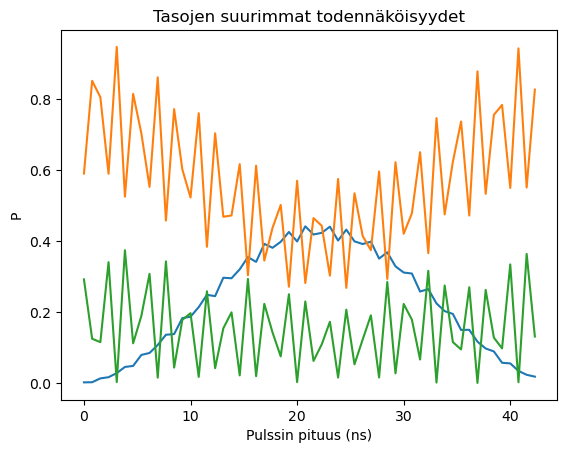

---------------------------------------------


In [45]:
m=1
vals = sim_pulse(qubit.frequency/3-0.32849600447317323,A_max,evolution_eigenbasis,dim,0.023328816932856315)

print("Amplitudi (GHz):", A_max)

print("Ajotaajuus AC Stark (GHz):", AC_stark_vals[-1])

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])

g_vals=np.array([np.abs(arr[0])**2 for arr in vals[3]])
e_vals=np.array([np.abs(arr[1])**2 for arr in vals[3]])
f_vals=np.array([np.abs(arr[2])**2 for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.plot(vals[4][:n_picked], g_vals[:n_picked])
plt.plot(vals[4][:n_picked], e_vals[:n_picked])
plt.plot(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")